Enter center x (xc): 0
Enter center y (yc): 3
Enter radius (r): 3

--- Bresenham's Circle Algorithm ---
Center point: (0, 3)
Radius: 3
Initial decision parameter d = -3 

x = 0 y = 3 d = -3 pixels -> [(0, 6), (0, 6), (0, 0), (0, 0), (3, 3), (-3, 3), (3, 3), (-3, 3)]
x = 1 y = 3 d = 3 pixels -> [(1, 6), (-1, 6), (1, 0), (-1, 0), (3, 4), (-3, 4), (3, 2), (-3, 2)]
x = 2 y = 2 d = 5 pixels -> [(2, 5), (-2, 5), (2, 1), (-2, 1), (2, 5), (-2, 5), (2, 1), (-2, 1)]


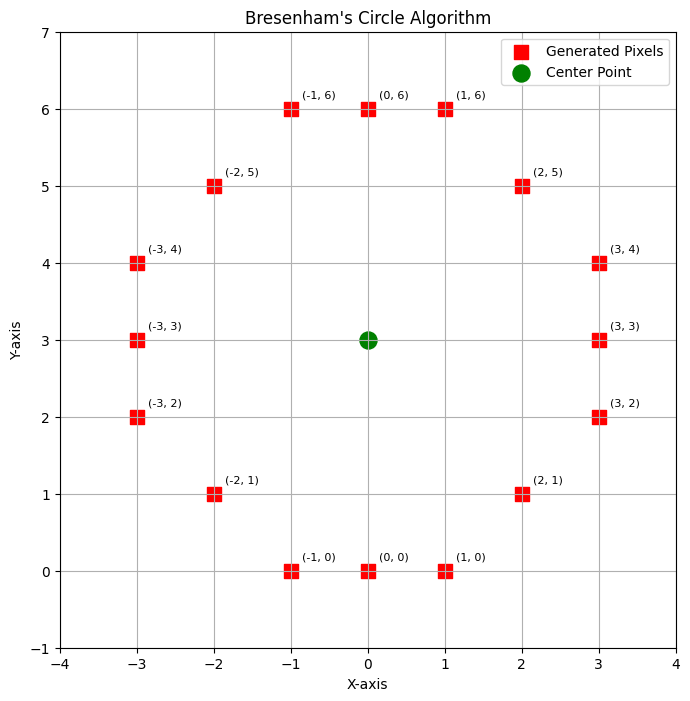

In [1]:
import matplotlib.pyplot as plt

def bresenham_circle(xc, yc, r):
    pixels = []
    print("\n--- Bresenham's Circle Algorithm ---")
    print("Center point:", (xc, yc))
    print("Radius:", r)

    x = 0
    y = r
    d = 3 - 2 * r

    print("Initial decision parameter d =", d, "\n")

    def plot_points(xc, yc, x, y):
        points = [
            (xc + x, yc + y), (xc - x, yc + y),
            (xc + x, yc - y), (xc - x, yc - y),
            (xc + y, yc + x), (xc - y, yc + x),
            (xc + y, yc - x), (xc - y, yc - x)
        ]
        for p in points:
            if p not in pixels:
                pixels.append(p)
        print("x =", x, "y =", y, "d =", d, "pixels ->", points)

    plot_points(xc, yc, x, y)

    step = 0
    while x < y:
        step += 1
        # decision parameter uses CURRENT x, BEFORE incrementing it
        if d < 0:
            d = d + 4 * x + 6
        else:
            d = d + 4 * (x - y) + 10
            y -= 1
        x += 1  # x increments AFTER the decision, not before

        plot_points(xc, yc, x, y)

    return pixels


xc = int(input("Enter center x (xc): "))
yc = int(input("Enter center y (yc): "))
r = int(input("Enter radius (r): "))

pixels = bresenham_circle(xc, yc, r)

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 8))

plt.scatter(
    x_pixels, y_pixels,
    s=100, marker="s", color="red",
    label="Generated Pixels"
)

plt.scatter(
    [xc], [yc],
    s=150, marker="o", color="green",
    label="Center Point"
)

for x, y in pixels:
    plt.annotate(
        f"({x}, {y})",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8
    )

plt.xticks(range(xc - r - 1, xc + r + 2))
plt.yticks(range(yc - r - 1, yc + r + 2))
plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Bresenham's Circle Algorithm")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()